In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [10]:
print(tf.__version__)
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images.shape

2.20.0


(60000, 28, 28)

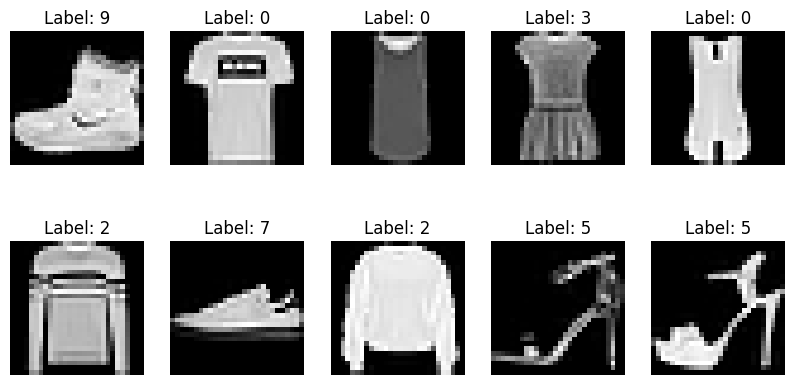

In [11]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

In [16]:
train_images = train_images / 255.0
test_images = test_images / 255.0
train_label_onehot = tf.keras.utils.to_categorical(train_labels) # 10 len arr needed for label 0~9 for one-hot encoding.
test_label_onehot = tf.keras.utils.to_categorical(test_labels)
train_label_onehot.shape

(60000, 10)

In [17]:
print(train_labels)
print(train_label_onehot)

[9 0 0 ... 3 0 5]
[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## Layers

Layer 由多個 Neurons(Units) 組成，每一個 Neurons 會將(多個)輸入值 $x_{i}$ 分別乘以對應的權重 $w_{i}$，再加上 bias, b，公式為：

$$\sum (x_{i}\cdot w_{i})+b$$

每個 Neuron 都會使用 Activation Function（例如 ReLU、Sigmoid 或 Tanh），決定該神經元是否被激發。<br>
如：以下代表 Dense layer 有 120 個 Neurons，每個 Neuron 使用 activation function - relu
```py
tf.keras.layers.Dense(120, activation='relu')
```
Notes: <br>
Neurons 由單個/多個 $x_i*w_i+b$ 組成。

### `Dense`
Dense 是全連接層(fully-connected neural network)：每個輸入節點都會連到每個輸出節點。

$params = inputs*units+units(bias)$

例：
```py
# inputs=3 features
Dense(2)
```
$params=3*2+2=8$<br>
`*2`：2 個 neurons。<br>
`+2`：每個 neuron 各有一個 bias（b）。<br>
`8`：可訓練參數。


### `Conv2D`
二維卷積層（Convolution），常處理影像資料。使用小型的「濾鏡（filter / kernel）」在影像上滑動，以找出邊緣、紋理等局部特徵。<br>
卷積核在不同位置「重複使用同一組權重」，所以參數量不會隨影像寬高增加；是卷積層適合影像的重要原因。

$params=(kernel\_height \times kernel\_width \times input\_channels)\times filters + filters'\ bias$

- 卷積核大小：`kernel_height * kernel_width`
- 輸入通道數：`input_channels`
- 濾鏡數量：`filters`
- 一個 filter 要覆蓋所有 $input\_channels$，因此有<br>$kernel\_height \times kernel\_width \times input\_channels$ 個權重。
每個濾鏡通常還有 1 個 bias。
- 有多少個 filters，就有多少組這樣的權重與 bias。

例：
```py
Conv2D(filters=2, kernel_size=(5,5))
```
輸入是 RGB 圖片，即 3 個 Channels：<br>
$params=(5 \times 5 \times 3) \times 2 + 2 = 152$ 個可訓練參數。

`channel`: 以 RGB 圖來看，RGB 以`（255, 255, 255）`組成，所以有三個參數位，即為 channels 數。<br>


### `MaxPooling2D`
將一小塊區域中的最大值留下，例如 2*2 區域取一個最大值，使特徵圖的寬、高縮小。<br>
例如：<br>
$$\begin{bmatrix}1 & 5\\3 & 2\end{bmatrix}\rightarrow 5$$
功能是降低資料尺寸、減少後續運算量，同時保留較明顯的特徵訊號。


In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=6,
        kernel_size=(5, 5),         # 每次查看影像中的 5*5 區域。
        activation='relu', 
        input_shape=(28, 28, 1)),   # 影像長寬。
    tf.keras.layers.MaxPooling2D((2, 2)), # 會把特徵圖縮小，保留每個小區域中最大的值。
    tf.keras.layers.Conv2D(filters=16, kernel_size=(5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120, activation='relu'),
    tf.keras.layers.Dense(84, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    train_images, 
    train_label_onehot, 
    epochs=10,
    validation_split=0.3)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6182 - loss: 1.0012 - val_accuracy: 0.7263 - val_loss: 0.7279
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7270 - loss: 0.7115 - val_accuracy: 0.7471 - val_loss: 0.6542
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7533 - loss: 0.6443 - val_accuracy: 0.7693 - val_loss: 0.6229
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7768 - loss: 0.5903 - val_accuracy: 0.7894 - val_loss: 0.5694
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7965 - loss: 0.5457 - val_accuracy: 0.8058 - val_loss: 0.5247
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8108 - loss: 0.5095 - val_accuracy: 0.8159 - val_loss: 0.5048
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8217 - loss: 0.4836 - val_accuracy: 0.8267 - val_loss: 0.4740
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8312 - loss: 0.4590 -

In [26]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

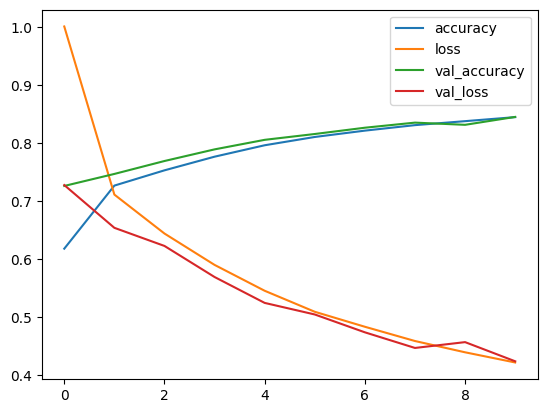

In [27]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

In [29]:
result = model.predict(test_images)
result

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[2.22930030e-08, 3.23371156e-11, 9.83149562e-09, ...,
        1.14911884e-01, 6.03310837e-05, 8.78063321e-01],
       [2.49065139e-04, 2.26942757e-06, 9.85920966e-01, ...,
        2.52023818e-10, 4.71569016e-04, 9.31149913e-09],
       [4.37076960e-05, 9.99840140e-01, 8.21208346e-07, ...,
        6.03598508e-12, 1.82123722e-06, 3.27050600e-07],
       ...,
       [1.93122728e-03, 3.15924931e-09, 1.55185280e-05, ...,
        4.34259277e-07, 9.90508437e-01, 1.30060296e-09],
       [7.53729910e-05, 9.95742738e-01, 3.71423994e-06, ...,
        2.87656204e-10, 2.36310512e-07, 1.23572436e-05],
       [1.20410645e-04, 1.16026706e-06, 1.54437308e-04, ...,
        3.48521650e-01, 2.20751278e-02, 7.84792472e-03]], dtype=float32)

In [31]:
import numpy as np
np.argmax(result, axis=1)

array([9, 2, 1, ..., 8, 1, 5])

In [32]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)